# Kinematics figures

1. Imports and recording parameters
2. Load the DataStructure and apply the existing training protocol
3. Choose the first eight filtered trials
4. Calculate speed and head rotation on the complete recording, then slice the measurements
5. Define the linear-speed and angular-head-velocity plotting functions
6. Return each figure in its own cell

Both figures use the original recording clock and 25-second rows, as in
`spatial_fixed`. Calculations happen before trial slicing so trial cuts do not
change the neighbouring samples used to calculate velocity.


In [11]:
##### Imports #########################################################
from pathlib import Path
import matplotlib.pyplot as plt
import movement.kinematics
import movement.utils.vector
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Markdown, display



from data_conduit.datastructures import slice_stream, slice_stream_per_trial
from movement_figures.data_template.loading import build_datastructure

from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from movement_figures.timeseries_template.annotations import annotate_qc_timeseries



from data_conduit.refactor_qc import (                                          # Imports for trial filtering based on experiment protocol 
    TRAINING_FIRST_MID_LAST_DETAIL,
    training_spec,
    training_session_names,
    filter_trials,
)


from data_conduit.integrations.DLC.pose import pose_to_movement                 # Import for combining DLC pose & confidence streams into single object, matches `movement`'s conventions


### Notebook Settings ######################################################

pd.set_option("display.max_columns", None)                              # Changes default pandas display settings to show all columns in a dataframe.


In [12]:
##### Setup Parameters ################################################


# === 1| Select Mice, Days and Recording Folders Before Reading Files =============

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                               # Example choices belong here: l0_selector and l1_selector.

# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                          # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                      # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                  # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                      # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering. 



In [13]:
##### Load DataStructure ###############################################################


#=== Load data ========================================================================
fig_ds = build_datastructure(
    root = ROOT,                                                                        # Directory above the named hierarchy levels.
    level_names = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams = ("trials", "session_settings", "video", "dlc"),
    include = None,                                                                     # Keep these session folder names; None keeps all.
    exclude = None,                                                                     # Alternatively omit these session folder names.
    raw_events = True,                                                                  # Convenience alias for adding "events" to the requested sources.
    device_yaml = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml = "./soundcard.yml",                                                 # Lab SoundCard register definitions.
    nosepoke_count = 18,                                                                # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                           # Preserve the existing lab parser setting.
    trial_spec = None,                                                                  # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.

    dlc_file_format = "auto",                                                           # Existing reader prefers CSV, otherwise HDF5.
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds.select()
streams = fig_ds.load()



#=== Create convenient compact trial dataframe without some unnecessary columns. ======
#       More useful for visual inspection and analysis. 
#       Check the misc.py file for the default columns to keep and drop. 

streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                            # Whether to modify the trial dataframe in place or return a new dataframe. 
)


#=== Apply Trial Filtering Protocol to construct new stream objects ===================
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"], #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], #selectors={"session": session_id}
    ),
)
display(streams['dlc:movement'])


#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,
    show_stream_shapes = True,
    show_stream_dtypes = True,
    display_streams = False
)

     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


<xarray.Dataset> Size: 8MB
Dimensions:     (individual: 1, keypoint: 5, space: 2, time: 36354)
Coordinates:
  * individual  (individual) object 8B 'individual_0'
  * keypoint    (keypoint) <U8 160B 'nose' 'lear' 'rear' 'body' 'tailbase'
  * space       (space) <U1 8B 'x' 'y'
  * time        (time) float64 291kB 5.633e+03 5.633e+03 ... 7.451e+03 7.451e+03
    session     (time) <U18 3MB '2026-06-21T093349Z' ... '2026-06-21T093349Z'
    mouseID     (time) object 291kB 'MR_M01569515' ... 'MR_M01569515'
    day         (time) object 291kB 'Day21' 'Day21' 'Day21' ... 'Day21' 'Day21'
Data variables:
    position    (time, space, keypoint, individual) float64 3MB 1.209e+03 ......
    confidence  (time, keypoint, individual) float64 1MB 0.9686 1.0 ... 0.9815
Attributes:
    source_software:  DeepLabCut
    time_unit:        seconds
    spatial_unit:     pixels

=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


In [14]:
##### Select the Trials and Recording #####

# Use the same first eight filtered trials as spatial_fixed.
selected_trials = slice_stream(streams['filtered_trials'][:6])
display(selected_trials)

# Use the single recording named by these trial rows.
session_id = selected_trials["session"].unique().item()
position = slice_stream(
    streams['dlc:movement'], selectors={"session": session_id},
)["position"].sel(individual="individual_0", drop=True)


,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,TTT,TTP,outbound_start_time,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day,training_day,day_trial_index
0,24,5922.650944,5930.218816,False,True,332,345,5928.000992,5925.144000,0,0,Success,OFF,0.0,300.0,5.350048,2.217824,5922.650944,5928.000992,False,True,5928.000992,5930.218816,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,1
1,25,5930.218816,5937.076640,False,True,346,359,5935.200000,5932.724000,0,0,Success,OFF,0.0,300.0,4.981184,1.876640,5930.218816,5935.200000,False,True,5935.200000,5937.076640,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,2
2,26,5937.076640,5947.709248,False,True,360,373,5944.049984,5939.589984,0,0,Success,OFF,0.0,300.0,6.973344,3.659264,5937.076640,5944.049984,False,True,5944.049984,5947.709248,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,3
3,27,5947.709248,5956.329760,False,True,374,387,5953.200000,5950.220992,0,0,Success,OFF,0.0,300.0,5.490752,3.129760,5947.709248,5953.200000,False,True,5953.200000,5956.329760,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,4
4,28,5956.329760,5963.959072,False,True,388,401,5962.250976,5958.838976,0,0,Success,OFF,0.0,300.0,5.921216,1.708096,5956.329760,5962.250976,False,True,5962.250976,5963.959072,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,5
5,29,5963.959072,5980.614496,False,True,402,415,5975.602976,5970.956992,-1,0,Miss,OFF,NaN,150.0,11.643904,5.011520,5963.959072,5975.602976,False,True,5975.602976,5980.614496,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,6


In [15]:
##### Calculate Measurements on the Complete Recording #####

# --- Body speed in pixels per second ---
# movement differentiates using the recorded time in seconds, then takes
# the magnitude of the x/y velocity. Trial slicing happens in the next cell.
point = position.sel(keypoint="body", drop=True)
linear_speed = movement.kinematics.compute_speed(point)
linear_speed = linear_speed.where(point.notnull().all("space"))  # Omit missing body positions.

# --- Head rotation in radians per second ---
# Anatomical left/right ears define forward for this top-down camera.
head_direction = movement.kinematics.compute_head_direction_vector(
    data=position, 
    left_keypoint="lear", 
    right_keypoint="rear",
    camera_view="top_down",
)
# shift(time=1) pairs each current sample with the previous acquired sample.
# The signed angle handles crossing -pi/pi without creating a full-turn jump.
head_rotation = movement.utils.vector.compute_signed_angle_2d(
    u=head_direction.shift(time=1), v=head_direction,
)
elapsed_seconds = head_direction["time"] - head_direction["time"].shift(time=1)
angular_head_velocity = head_rotation / elapsed_seconds
# Each value describes the preceding interval; the recording's first is NaN.
# With image y increasing downwards, positive rotation is clockwise.


In [16]:
##### Slice the Measurements to the Selected Trials #####

# Each slicer returns one array per trial, respecting its time boundaries.
selected_linear_speed = slice_stream_per_trial(
    stream=linear_speed, 
    trials=selected_trials, 
    segment="trial", 
    time_coord="time",
)
selected_linear_speed = xr.concat(selected_linear_speed, dim="time")

selected_angular_head_velocity = slice_stream_per_trial(
    stream=angular_head_velocity, 
    trials=selected_trials, 
    segment="trial", 
    time_coord="time",
)
selected_angular_head_velocity = xr.concat(selected_angular_head_velocity, dim="time")
# Concatenation retains recording times. The plots use points so excluded
# intervals remain blank instead of being joined by a line.


# Figure functions

The functions draw the supplied measurements and matching trial annotations.
They do not change trial selection, calculate derivatives or apply smoothing.
Speed is in pixels per second; angular head velocity is in radians per second.


In [17]:
##### Linear Locomotion Speed #####

def plot_linear_speed(linear_speed, 
                      selected_trials, 
                      *, 
                      row_duration_s=60.0):
    """Plot body speed over the selected trials in equal-duration rows.

    The measurement cell uses movement.kinematics.compute_speed on the whole
    recording before slicing. Speed is the magnitude of x/y velocity, so it
    has no direction and cannot be negative. Missing positions remain gaps.

    Parameters
    ----------
    linear_speed : xarray.DataArray
        Already-calculated body speed for one individual, sliced to the
        selected trials. Values are pixels per second and time contains
        increasing recording times in seconds. Keep the original time values;
        they place trial gaps and annotations at their recorded positions.
    selected_trials : pandas.DataFrame
        The matching trial rows used to slice linear_speed. Their original
        DataStructure columns supply phase shading and event annotations.
        No trial filtering or additional selection happens in this function.
    row_duration_s : float
        Positive number of recording seconds displayed on each row.
        All rows share the same duration and y scale. The final row keeps
        its full width even when fewer samples remain.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Linear-speed figure, ready to display or save.
    axes : numpy.ndarray
        One-dimensional array of row axes, from earliest to latest time.
        The supplied speed values are plotted unchanged.
    """
    # --- Divide the recording clock into equal-duration rows ---
    start = float(linear_speed["time"][0])
    end = float(linear_speed["time"][-1])
    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    fig, grid = plt.subplots(
        row_count, 1, figsize=(13, 2.6 * row_count),
        squeeze=False, sharey=True, layout="constrained",
    )
    axes = grid[:, 0]

    # --- Draw speed and the matching trial annotations ---
    for row, ax in enumerate(axes):
        row_start = start + row * row_duration_s
        row_end = row_start + row_duration_s
        # Points keep missing or excluded intervals unconnected.
        ax.plot(linear_speed["time"], linear_speed, ".", ms=2.5, color="#5b4b9a")
        ax.set(
            xlim=(row_start, row_end),
            xlabel="Recording time (s)", ylabel="Linear speed (px/s)",
        )
        ax.set_ylim(bottom=0)  # Speed is a magnitude.
        ax.grid(axis="y", alpha=0.2)
        annotate_qc_timeseries(
            ax, selected_trials, window=(row_start, row_end),
        )

    fig.suptitle("Body linear speed")
    return fig, axes


In [ ]:
##### Angular Head Velocity #####

def plot_angular_head_velocity(
    angular_head_velocity, 
    selected_trials, 
    *, 
    row_duration_s=60.0,
    units = 'deg/s'
):
    """Plot the signed rate of head rotation over the selected trials.

    The measurement cell uses movement to calculate the angle from each
    previous head-forward vector to the current vector, then divides by
    elapsed seconds. Values describe the preceding acquired interval.
    Positive means clockwise in video coordinates, where y increases down;
    negative means anticlockwise. Zero means no change in head direction.

    Parameters
    ----------
    angular_head_velocity : xarray.DataArray
        Signed angular velocity in radians per second for one individual,
        calculated on the whole recording before slicing to selected trials.
        time contains increasing recording times in seconds. The recording's
        first sample and intervals touching missing or coincident ears are
        NaN. The signed inter-frame angle avoids a jump at -pi/pi, but cannot
        distinguish rotations larger than half a turn between acquired frames.
    selected_trials : pandas.DataFrame
        The matching trial rows used to slice angular_head_velocity. Their
        original DataStructure columns supply phase shading and event
        annotations. This function makes no additional trial selection.
    row_duration_s : float
        Positive number of recording seconds displayed on each row.
        All rows share the same duration and y scale. The final row keeps
        its full width even when fewer samples remain.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Angular-head-velocity figure, ready to display or save.
    axes : numpy.ndarray
        One-dimensional array of row axes, from earliest to latest time.
        The supplied angular velocities are plotted unchanged.
    """

    #=== Convert units if needed ===
    if units == 'deg/s':
        angular_head_velocity = np.rad2deg(angular_head_velocity)
    elif units == 'rad/s':
        pass
    else:
        raise ValueError(f"Invalid units: {units}. Must be 'deg/s' or 'rad/s'.")


    # --- Divide the recording clock into equal-duration rows ---
    start = float(angular_head_velocity["time"][0])
    end = float(angular_head_velocity["time"][-1])
    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    fig, grid = plt.subplots(
        row_count, 1, figsize=(13, 2.6 * row_count),
        squeeze=False, sharey=True, layout="constrained",
    )
    axes = grid[:, 0]

    # --- Draw signed velocity and the matching trial annotations ---
    for row, ax in enumerate(axes):
        row_start = start + row * row_duration_s
        row_end = row_start + row_duration_s
        # Points keep missing or excluded intervals unconnected.
        ax.plot(
            angular_head_velocity["time"], angular_head_velocity,
            ".", ms=2.5, color="#5b4b9a",
        )
        ax.axhline(0, color="0.5", linewidth=0.8)  # Separate the two rotation directions.
        ax.set(
            xlim=(row_start, row_end),
            xlabel="Recording time (s)", ylabel="Angular head velocity (rad/s)",
        )
        ax.grid(axis="y", alpha=0.2)
        annotate_qc_timeseries(
            ax, selected_trials, window=(row_start, row_end),
        )
        #ax.set_ylim(-360, 360)

    fig.suptitle("Angular head velocity")
    return fig, axes


# Return the figures

Both cells use the same eight trial rows and the measurements sliced above.
Change `row_duration_s` to change the displayed duration of every row.


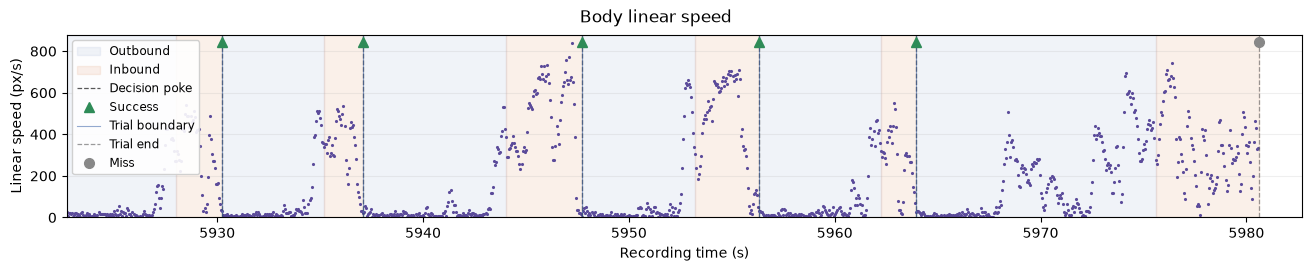

In [19]:
##### Return Linear Locomotion Speed #####

linear_speed_figure, linear_speed_axes = plot_linear_speed(
    linear_speed=selected_linear_speed, 
    selected_trials=selected_trials,
    row_duration_s=60.0,
)
linear_speed_figure.savefig("linear_speed_figure.png")
plt.close(linear_speed_figure)  # Display the returned figure once below.
linear_speed_figure


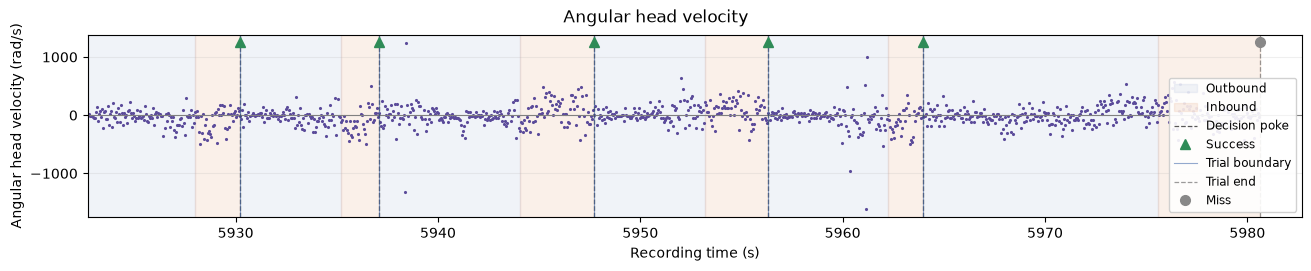

In [23]:
##### Return Angular Head Velocity #####

angular_head_velocity_figure, angular_head_velocity_axes = plot_angular_head_velocity(
    angular_head_velocity=selected_angular_head_velocity,
    selected_trials=selected_trials, 
    row_duration_s=60.0,
)
angular_head_velocity_figure.savefig("angular_head_velocity_figure.png")
plt.close(angular_head_velocity_figure)  # Display the returned figure once below.
angular_head_velocity_figure
